# Somalia workflow: Step 4: Station selection

NGA step 4 adapted: rank candidates by best lag-adjusted Spearman rho and
keep the top set for the action-trigger grid search. Somalia departures:

1. **Benchmark = SWALIM** (step 3 settled this: median rho 0.65-0.86 vs
   SFED's 0.21-0.46 with spurious negatives).
2. **Per river x season** selections (Gu and Deyr are separate windows).
3. **Operational eligibility filter**: a selected series must have a usable
   forecast product. `google_grrr` (reforecast 2016-2023 + live Flood Hub)
   and `glofas_v4` (reforecast 2003-2023 + operational forecast) qualify.
   `glofas_v5` (no reforecast exists) and `geoglows` (forecast climatology
   incompatible with retrospective-fitted thresholds; no reforecast archive)
   are shown for reference but not selectable.
4. **One source per station**: consensus should be spatial, not the same
   water level seen through two models. Per station keep its best-rho
   eligible source.

**Output**: `som_selected_stations.parquet`: per (river, season): the
selected (station, source) set with best_rho/best_lag.

In [1]:
import sys

sys.path.insert(0, "..")

import os
import tempfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ocha_stratus as stratus
import geopandas as gpd, tempfile, os

from src.constants import (
    TRIGGER_STATIONS,
    ALL_TRIGGER_STATIONS,
    RIVER_MODEL,
    SEASONS,
    SEASON_MONTHS,
    EXP_SEASONS,
    STATIONS,
    INK,
    BODY,
    FAINT,
    GRID,
    C_MOD,
    C_HIGH,
    C_GU,
    C_DEYR,
    C_JUBA,
    C_SHAB,
    C_MAIN,
    C_ISOL,
    C_JOINT,
    C_BAND,
    C_BAND_EDGE,
    C_REF,
    C_GEOGLOWS,
    C_GOOGLE,
    C_GLOFAS4,
    C_GLOFAS5,
    C_SWALIM,
    C_SFED,
    SOURCE_COLORS,
)
from src.plots import apply_chart_style, style_ax
from src.utils import (
    auc,
    episodes,
    gumbel_rp,
    hits,
    weibull_level,
    weibull_threshold,
    yT,
)

apply_chart_style()


In [2]:
def load(name):
    return stratus.load_parquet_from_blob(f"ds-aa-som-floods/processed/{name}.parquet", stage="dev")

corr = load("workflow/som_gauge_correlations")  # reanalysis screen (nb06)
sw = corr[(corr.benchmark == "swalim") & corr.station.isin(ALL_TRIGGER_STATIONS)]

# The station set is FIXED by the gauge restriction, so this notebook no
# longer ranks stations: every reporting gauge on a river is in. What it
# still has to decide is which single model carries each river. The test is
# the weakest of the two seasons, since one model must serve both.
print("Mean best-lag rho at the trigger gauges, by model and season:\n")
for river, stns in TRIGGER_STATIONS.items():
    per = (
        sw[sw.river == river]
        .pivot_table(index="source", columns="season", values="best_rho", aggfunc="mean")
        .round(3)
    )
    per["worst_season"] = per[["gu", "deyr"]].min(axis=1)
    per = per.sort_values("worst_season", ascending=False)
    print(f"{river.capitalize()} ({len(stns)} gauges: {', '.join(stns)})")
    print(per.to_string(), "\n")
    if per.index[0] != RIVER_MODEL[river]:
        print(
            f"  note: correlation alone would favour {per.index[0]} here; the adopted"
            f" choice is {RIVER_MODEL[river]} on event detection and 2023 coverage"
            " (notebook 08).\n"
        )

# selection = every trigger gauge, carried by its river's model
rows = []
for river, stns in TRIGGER_STATIONS.items():
    model = RIVER_MODEL[river]
    for season in ["gu", "deyr"]:
        for station in stns:
            c = sw[
                (sw.river == river)
                & (sw.season == season)
                & (sw.source == model)
                & (sw.station == station)
            ]
            if not len(c):
                print(f"  ! no correlation row for {station} {season} {model}")
                continue
            c = c.iloc[0]
            rows.append(
                {
                    "river": river,
                    "season": season,
                    "station": station,
                    "source": model,
                    "best_rho": c.best_rho,
                    "best_lag": c.best_lag,
                }
            )
sel = pd.DataFrame(rows)
print(sel.groupby(["river", "season"]).size().rename("n_stations").to_string())
sel


Mean best-lag rho at the trigger gauges, by model and season:

Juba (4 gauges: luuq, dollow, bardheere, bualle)
season        deyr     gu  worst_season
source                                 
glofas_v5    0.828  0.828         0.828
geoglows     0.804  0.820         0.804
google_grrr  0.534  0.861         0.534 

  note: correlation alone would favour glofas_v5 here; the adopted choice is google_grrr on event detection and 2023 coverage (notebook 08).

Shabelle (3 gauges: belet_weyne, bulo_burti, jowhar)
season        deyr     gu  worst_season
source                                 
glofas_v5    0.818  0.739         0.739
geoglows     0.735  0.808         0.735
google_grrr  0.627  0.791         0.627 

  note: correlation alone would favour glofas_v5 here; the adopted choice is google_grrr on event detection and 2023 coverage (notebook 08).

river     season
juba      deyr      4
          gu        4
shabelle  deyr      3
          gu        3


,river,season,station,source,best_rho,best_lag
0,juba,gu,luuq,google_grrr,0.866,0
1,juba,gu,dollow,google_grrr,0.848,3
2,juba,gu,bardheere,google_grrr,0.869,-1
3,juba,gu,bualle,google_grrr,0.863,-1
4,juba,deyr,luuq,google_grrr,0.576,-5
5,juba,deyr,dollow,google_grrr,0.598,-2
6,juba,deyr,bardheere,google_grrr,0.503,-10
7,juba,deyr,bualle,google_grrr,0.458,-10
8,shabelle,gu,belet_weyne,google_grrr,0.808,6
9,shabelle,gu,bulo_burti,google_grrr,0.786,4


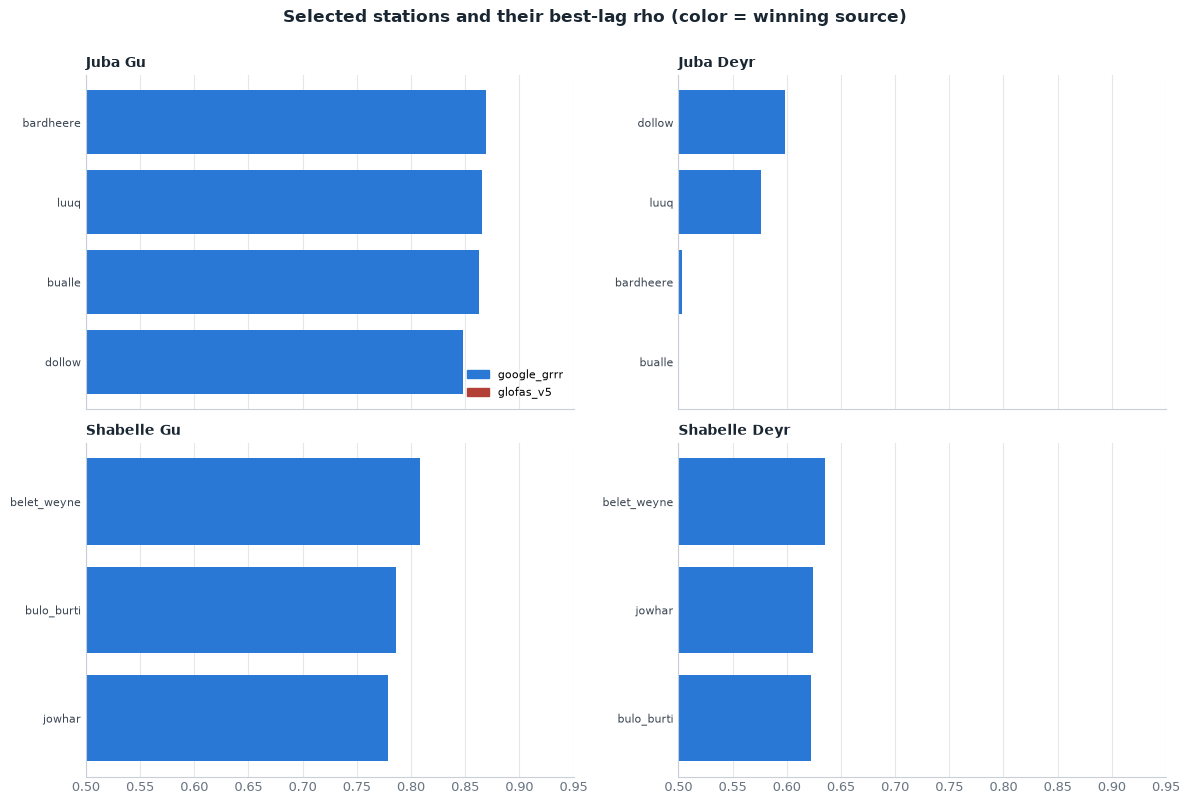

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
combos = [("juba", "gu"), ("juba", "deyr"), ("shabelle", "gu"), ("shabelle", "deyr")]
for ax, (river, season) in zip(axes.ravel(), combos):
    sub = sel[(sel.river == river) & (sel.season == season)].sort_values("best_rho")
    ax.barh(sub.station, sub.best_rho, color=[SOURCE_COLORS[s] for s in sub.source])
    ax.set_xlim(0.5, 0.95)
    ax.set_title(f"{river.capitalize()} {season.capitalize()}", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    style_ax(ax)
axes.ravel()[0].legend(
    handles=[
        mpatches.Patch(color=SOURCE_COLORS["google_grrr"], label="google_grrr"),
        mpatches.Patch(color=SOURCE_COLORS["glofas_v5"], label="glofas_v5"),
    ],
    fontsize=8,
    loc="lower right",
)
fig.suptitle("Selected stations and their best-lag rho (color = winning source)",
             fontweight="bold", color=INK, fontsize=12, y=1.0)
plt.tight_layout()


## Reference: how the ineligible sources would have ranked

In [4]:
ref = corr[corr.benchmark == "swalim"].copy()
piv = ref.pivot_table(index=["river", "season"], columns="source",
                      values="best_rho", aggfunc="median").round(2)
piv


source           geoglows  glofas_v5  google_grrr
river    season                                  
juba     deyr        0.81       0.83         0.54
         gu          0.82       0.83         0.86
shabelle deyr        0.74       0.82         0.62
         gu          0.81       0.75         0.79

## Selected stations on the map, sized by rho

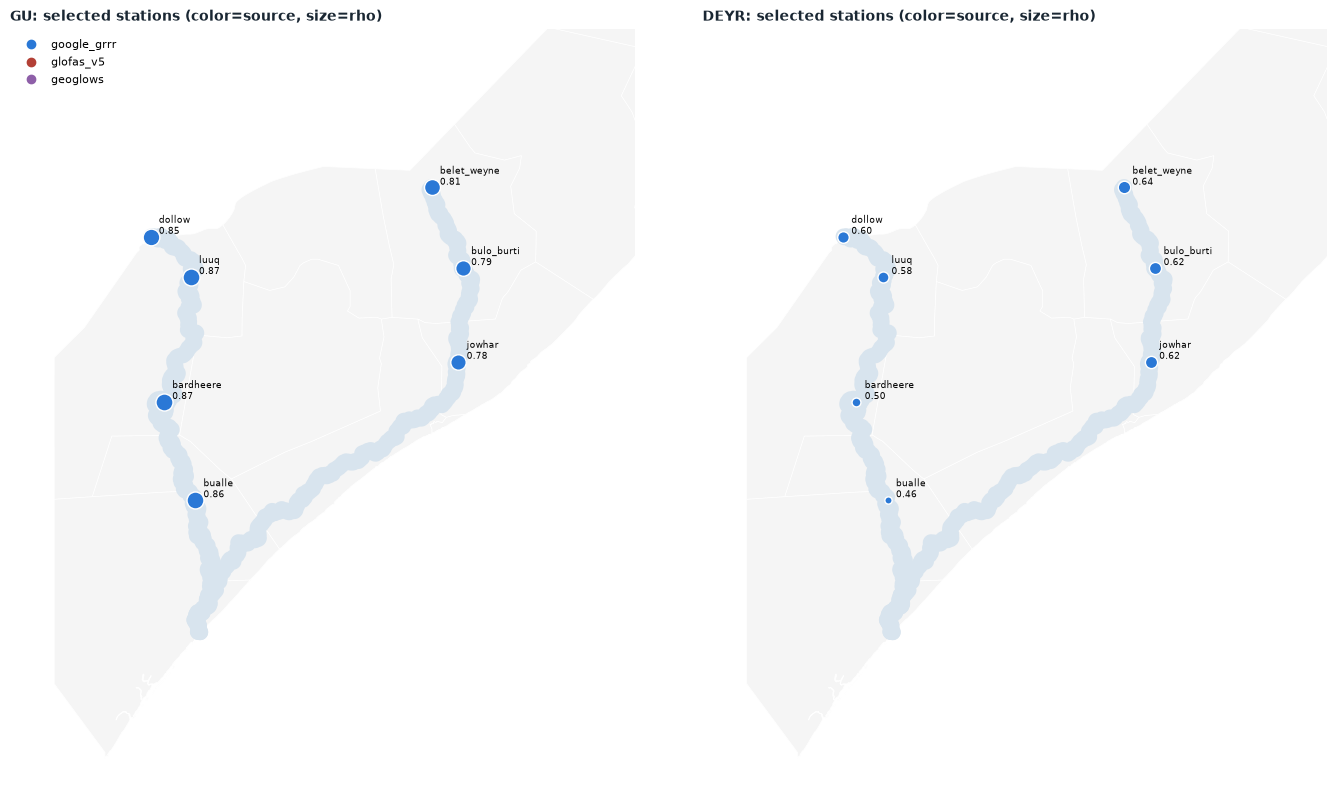

In [5]:
adm1 = stratus.codab.load_codab_from_blob("som", admin_level=1)
_raw = stratus.load_blob_data("ds-aa-som-floods/processed/workflow/som_river_buffers.gpkg", stage="dev")
_tmp = os.path.join(tempfile.gettempdir(), "som_river_buffers.gpkg")
open(_tmp, "wb").write(_raw)
bufs = gpd.read_file(_tmp)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
SRC_COLORS = {"google_grrr": C_GOOGLE, "glofas_v5": C_GLOFAS5,
              "geoglows": C_GEOGLOWS}
for ax, season in zip(axes, ["gu", "deyr"]):
    adm1.plot(ax=ax, color="#F5F5F5", edgecolor="white", linewidth=0.5)
    bufs.plot(ax=ax, color="#D8E4EE")
    sub = sel[sel.season == season]
    for _, r in sub.iterrows():
        st = STATIONS[r.station]
        ax.scatter(st.lon, st.lat, s=40 + 300 * (r.best_rho - 0.5),
                   color=SRC_COLORS[r.source], edgecolors="white", zorder=5)
        ax.annotate(f"{r.station}\n{r.best_rho:.2f}", (st.lon, st.lat),
                    textcoords="offset points", xytext=(6, 2), fontsize=6.5)
    ax.set_title(f"{season.upper()}: selected stations (color=source, size=rho)", loc="left", fontsize=10)
    ax.set_xlim(40.5, 47.5); ax.set_ylim(-2, 6.5)
handles = [plt.Line2D([], [], color=c, marker="o", ls="", label=s) for s, c in SRC_COLORS.items()]
axes[0].legend(handles=handles, fontsize=8, loc="upper left")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()


**On the GEOGloWS bias correction (notebook 02 section 4b).** It does not
change anything below. Every threshold here is a return period of each
model's own series, and the correction is monotonic within a month, so the
same days exceed and the same seasons activate. The corrected series matter
for reading discharge in real units and for thresholding GEOGloWS forecasts
(notebook 03), not for the trigger arithmetic. GEOGloWS is in any case not
among the selected sources.


## Save

In [6]:
stratus.upload_parquet_to_blob(
    sel, "ds-aa-som-floods/processed/workflow/som_selected_stations.parquet", stage="dev")
print(f"uploaded som_selected_stations.parquet ({len(sel)} rows)")


uploaded som_selected_stations.parquet (14 rows)
